Importing Dependencies -


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

IMPORTING THE DATASET --

In [3]:
df=pd.read_csv("tested.csv")

In [32]:
df['fam_memb']=df['Parch']+df['SibSp']+1

In [33]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,fam_memb
313,1205,1,3,"Carr, Miss. Jeannie",female,37.0,0,0,368364,7.7500,NaN,Q,1
92,984,1,1,"Davidson, Mrs. Thornton (Orian Hays)",female,27.0,1,2,F.C. 12750,52.0000,B71,S,4
284,1176,1,3,"Rosblom, Miss. Salli Helena",female,2.0,1,1,370129,20.2125,NaN,S,3


In [7]:
df.shape

(418, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [ ]:
df.isna().sum() , df.duplicated().sum()

(PassengerId      0
 Survived         0
 Pclass           0
 Name             0
 Sex              0
 Age             86
 SibSp            0
 Parch            0
 Ticket           0
 Fare             1
 Cabin          327
 Embarked         0
 dtype: int64,
 np.int64(0))

In [13]:
df[['Survived','Pclass','Age','Fare','SibSp','Parch']].corr()

,Survived,Pclass,Age,Fare,SibSp,Parch
Survived,1.000000,-0.108615,-0.000013,0.191514,0.099943,0.159120
Pclass,-0.108615,1.000000,-0.492143,-0.577147,0.001087,0.018721
Age,-0.000013,-0.492143,1.000000,0.337932,-0.091587,-0.061249
Fare,0.191514,-0.577147,0.337932,1.000000,0.171539,0.230046
SibSp,0.099943,0.001087,-0.091587,0.171539,1.000000,0.306895
Parch,0.159120,0.018721,-0.061249,0.230046,0.306895,1.000000


([<matplotlib.patches.Wedge at 0x1ecffae47d0>,
 [Text(-1.0629661397886532, 0.2830247085729615, '1'),
  Text(0.4123757910903645, -1.0197775281514083, '2'),
  Text(0.8793425294733509, 0.6608757189210459, '3')],
 [Text(-0.5797997126119926, 0.1543771137670699, '41.7%'),
  Text(0.22493224968565334, -0.5562422880825862, '28.8%'),
  Text(0.4796413797127368, 0.360477664866025, '29.5%')])

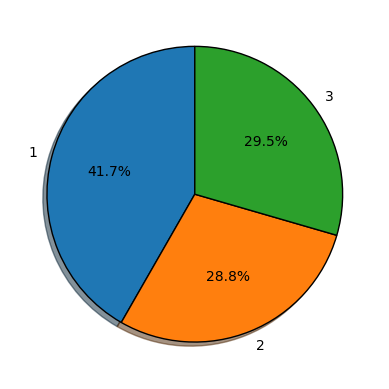

In [34]:
survive_pclass= df.groupby('Pclass')['Survived'].sum()
x=survive_pclass.index
y=survive_pclass.values/df.groupby('Pclass')['PassengerId'].count()

plt.pie(y,labels=x,shadow=True,startangle=90,autopct='%1.1f%%',
        wedgeprops={'edgecolor':'black'})

([<matplotlib.patches.Wedge at 0x1ecffea42d0>,
 [Text(1.311736850028664e-08, -1.0999999999999999, 'female'),
  Text(-3.715428635160957e-07, 1.0999999999999373, 'male')],
 [Text(7.1549282728836204e-09, -0.5999999999999999, '100.0%'),
  Text(-2.0265974373605219e-07, 0.5999999999999658, '0.0%')])

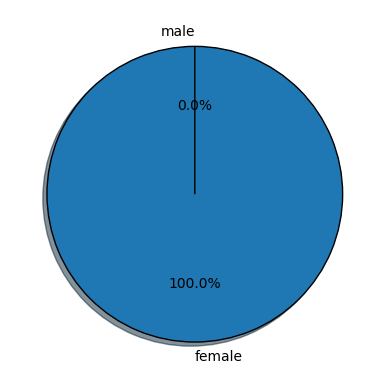

In [40]:
survive_sex= df.groupby('Sex')['Survived'].sum()
x=survive_sex.index
y=survive_sex.values/df.groupby('Sex')['PassengerId'].count()

plt.pie(y,labels=x,shadow=True,startangle=90,autopct='%1.1f%%',
        wedgeprops={'edgecolor':'black'})